<a href="https://colab.research.google.com/github/adityaaaa342/Pattern-Recognition-/blob/main/Practical_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import kagglehub

path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


In [10]:
import zipfile
import os
zip_file_name = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.zip'):
            zip_file_name = os.path.join(root, file)
            break
    if zip_file_name:
        break

if zip_file_name:
    print(f"Found zip file: {zip_file_name}")
    extract_to_path = os.path.join(path, 'extracted_dataset')
    os.makedirs(extract_to_path, exist_ok=True)
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(extract_to_path)
    print(f"Dataset extracted to: {extract_to_path}")
    dataset_path = extract_to_path
else:
    print("No zip file found. Assuming dataset is already unzipped or in a different format.")

    dataset_path = path

print("Dataset path for processing:", dataset_path)

Dataset found at: /kaggle/input/face-mask-dataset/data
Dataset path for processing: /kaggle/input/face-mask-dataset/data


Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Found 7553 files belonging to 2 classes.
Using 1510 files for validation.

Successfully loaded dataset. Let's inspect the classes and an example batch.
Classes found: ['with_mask', 'without_mask']


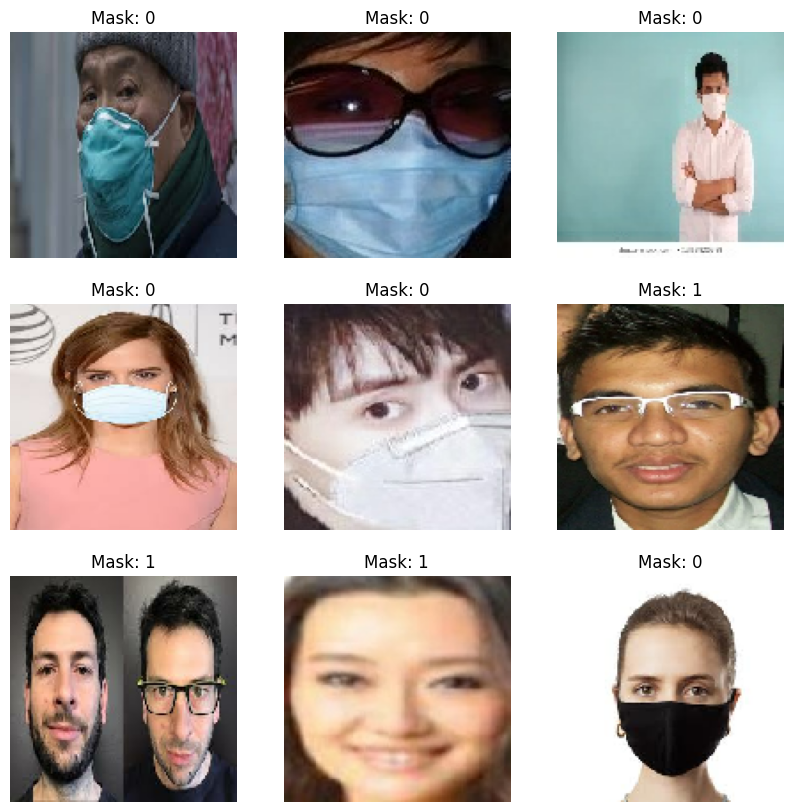

In [11]:
import tensorflow as tf

IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

try:
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
        labels='inferred',
        label_mode='binary',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42,
        validation_split=0.2,
        subset='training'
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
        labels='inferred',
        label_mode='binary',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42,
        validation_split=0.2,
        subset='validation'
    )

    print("\nSuccessfully loaded dataset. Let's inspect the classes and an example batch.")
    print("Classes found:", train_ds.class_names)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 10))
    for images, labels in train_ds.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Mask: {int(labels[i])}")
            plt.axis("off")
    plt.show()

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please check the dataset path and directory structure. It should contain subdirectories for each class (e.g., 'with_mask', 'without_mask').")
    print("The dataset path identified is:", dataset_path)

In [12]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset preprocessing complete.")

Dataset preprocessing complete.


In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("CNN model defined and compiled successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN model defined and compiled successfully!


In [15]:
EPOCHS = 3

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("Model training complete!")

Epoch 1/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 141s 748ms/step - accuracy: 0.8964 - loss: 0.2635 - val_accuracy: 0.9066 - val_loss: 0.2243
Epoch 2/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 139s 736ms/step - accuracy: 0.9149 - loss: 0.2169 - val_accuracy: 0.9086 - val_loss: 0.2205
Epoch 3/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 121s 643ms/step - accuracy: 0.9318 - loss: 0.1771 - val_accuracy: 0.9397 - val_loss: 0.1592
Model training complete!


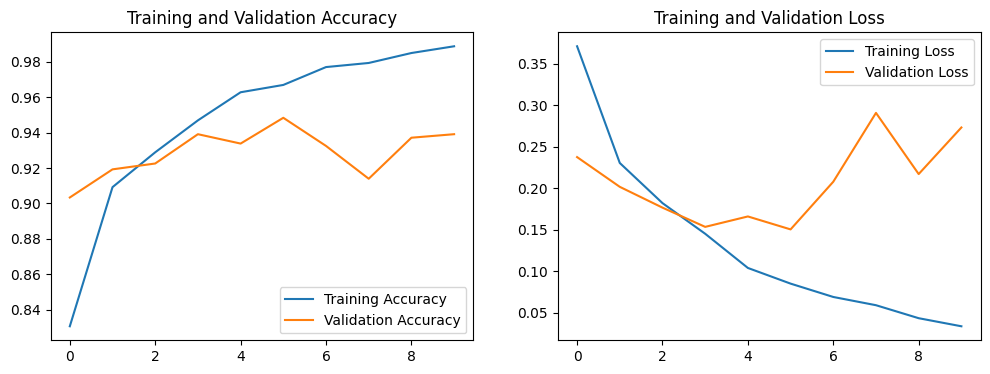

48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 282ms/step - accuracy: 0.9391 - loss: 0.2733
Validation Loss: 0.2733
Validation Accuracy: 0.9391


In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")